# 02. CATE and Uplift Modeling

The previous notebook introduced heterogeneous treatment effects and the CATE. This notebook focuses on uplift modeling, the industry-facing version of the same idea when the outcome is often binary: conversion, churn, renewal, click, purchase, activation, or default.

Uplift modeling asks a targeting question: who is more likely to respond because of the treatment? That is different from asking who is likely to convert. A customer can be likely to convert anyway. Another customer can have a modest baseline conversion probability but a large incremental response to the offer.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the relationship between uplift, CATE, and incremental response.
- Distinguish response modeling from uplift modeling.
- Describe the classic uplift segments: persuadables, sure things, lost causes, and sleeping dogs.
- Fit practical uplift scores using two-model, interaction-model, and transformed-outcome approaches.
- Evaluate uplift models with decile lift tables, cumulative uplift curves, AUUC-style summaries, and policy value.
- Explain why ordinary classification metrics can be actively misleading for treatment targeting.

### Dataset and Experiment Setup

This notebook uses a simulated marketing campaign with customer-level records. Each row represents a customer with pre-campaign behavior such as intent, price sensitivity, loyalty, visit frequency, and channel usage. The treatment is campaign exposure, and the outcome is a conversion or purchase response after the campaign. Some customers are persuadable, some would buy anyway, and some are low-value targets, which makes uplift modeling more realistic than a simple average-effect example.

The data is synthetic because the lesson requires known treatment-effect heterogeneity. In a real campaign, the true uplift for each customer is hidden. We can estimate effects by randomized holdouts, but we cannot directly observe whether an individual customer's purchase was caused by the campaign. The simulation lets the notebook compare predicted uplift, true uplift, top-bin lift, calibration, targeting value, and the difference between predictive accuracy and causal targeting quality.


In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def sigmoid(x):
    """Compute sigmoid for the cate and uplift modeling example.
    
    Inputs:
    - `x`: logit-scale numeric input converted into a probability.
    Returns: a NumPy array or scalar of logistic probabilities."""
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Construct the dag object.
    
    Inputs:
    - `edges`: directed or undirected graph edges represented as node pairs.
    - `title`: plot or graph title displayed above the figure.
    - `node_colors`: optional mapping from graph nodes to fill colors.
    - `rankdir`: Graphviz layout direction, such as left-to-right or top-to-bottom.
    Returns: a Graphviz diagram for the causal structure in the section."""
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def simulate_uplift_campaign(n=25_000, seed=5202):
    """Simulate the uplift campaign data-generating process.
    
    Inputs:
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)

    intent_score = rng.beta(2.0, 4.0, n)
    price_sensitivity = rng.beta(2.5, 2.0, n)
    loyalty_score = rng.beta(2.8, 1.8, n)
    visits_30d = rng.poisson(np.clip(1.0 + 7.0 * intent_score, 0.2, None))
    days_since_last_visit = np.clip(rng.gamma(2.0, 10.0, n) * (1.25 - intent_score), 1, 90)
    discount_history = rng.poisson(np.clip(0.3 + 2.4 * price_sensitivity, 0.1, None))
    mobile_app = rng.binomial(1, sigmoid(-0.6 + 1.4 * intent_score + 0.4 * loyalty_score), n)
    annual_contract = rng.binomial(1, sigmoid(-0.5 + 1.7 * loyalty_score - 0.8 * price_sensitivity), n)

    control_logit = (
        -3.4
        + 3.2 * intent_score
        + 1.4 * loyalty_score
        + 0.08 * visits_30d
        - 0.025 * days_since_last_visit
        - 0.75 * price_sensitivity
        + 0.35 * mobile_app
        + 0.45 * annual_contract
    )
    p0 = sigmoid(control_logit)

    raw_uplift = (
        0.16 * price_sensitivity * (1 - loyalty_score)
        + 0.09 * intent_score * price_sensitivity
        + 0.035 * mobile_app
        + 0.025 * (discount_history >= 2).astype(float)
        - 0.10 * loyalty_score * (1 - price_sensitivity)
        - 0.05 * annual_contract * (1 - price_sensitivity)
    )
    p1 = np.clip(p0 + raw_uplift, 0.002, 0.985)
    true_cate = p1 - p0

    treatment = rng.binomial(1, 0.5, n)
    y0 = rng.binomial(1, p0)
    y1 = rng.binomial(1, p1)
    converted = np.where(treatment == 1, y1, y0)

    return pd.DataFrame(
        {
            "customer_id": np.arange(1, n + 1),
            "intent_score": intent_score,
            "price_sensitivity": price_sensitivity,
            "loyalty_score": loyalty_score,
            "visits_30d": visits_30d,
            "days_since_last_visit": days_since_last_visit,
            "discount_history": discount_history,
            "mobile_app": mobile_app,
            "annual_contract": annual_contract,
            "treatment": treatment,
            "converted": converted,
            "p0": p0,
            "p1": p1,
            "true_cate": true_cate,
            "y0": y0,
            "y1": y1,
        }
    )


def top_fraction_mask(frame, score_col, fraction=0.20, largest=True):
    """Compute top fraction mask for the cate and uplift modeling example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `score_col`: name of the model-score column used for ranking, targeting, or validation.
    - `fraction`: fraction of units selected by a top-ranked targeting rule.
    - `largest`: whether larger scores should be treated as better when selecting top-ranked units.
    Returns: a Boolean mask or treatment rule selecting the highest-scoring share of units."""
    n_select = max(1, int(np.floor(fraction * len(frame))))
    selected_index = frame[score_col].sort_values(ascending=not largest).head(n_select).index
    mask = pd.Series(False, index=frame.index)
    mask.loc[selected_index] = True
    return mask


def response_rate_difference(frame, mask=None, outcome="converted", treatment="treatment"):
    """Compute response rate difference for the cate and uplift modeling example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `mask`: mask value used by `response_rate_difference`.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: a treatment-control contrast with estimate and uncertainty fields."""
    work = frame if mask is None else frame.loc[mask]
    treated = work.loc[work[treatment] == 1, outcome]
    control = work.loc[work[treatment] == 0, outcome]
    estimate = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / treated.size + control.var(ddof=1) / control.size)
    return {
        "n": len(work),
        "n_treated": treated.size,
        "n_control": control.size,
        "treated_rate": treated.mean(),
        "control_rate": control.mean(),
        "observed_uplift": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
    }


def make_interaction_frame(frame, feature_cols, treatment_value=None):
    """Construct the interaction frame object.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    - `treatment_value`: counterfactual treatment value used to build a design matrix under a fixed treatment state.
    Returns: the constructed design matrix, catalog, model object, or teaching object requested by the section."""
    base = frame[feature_cols].copy()
    treatment = frame["treatment"].to_numpy() if treatment_value is None else np.repeat(treatment_value, len(frame))
    for col in feature_cols:
        base[f"treat_x_{col}"] = treatment * frame[col].to_numpy()
    base["treatment"] = treatment
    return base


def cumulative_uplift_curve(frame, score_col, outcome="converted", treatment="treatment", propensity=0.5, n_grid=120):
    """Compute cumulative uplift curve for the cate and uplift modeling example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `score_col`: name of the model-score column used for ranking, targeting, or validation.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    - `propensity`: propensity value used by `cumulative_uplift_curve`.
    - `n_grid`: number of targeting thresholds used to trace the uplift or value curve.
    Returns: a curve-ready table showing value or uplift as the policy threshold changes."""
    work = frame.sort_values(score_col, ascending=False).reset_index(drop=True).copy()
    work["ipw_incremental"] = work[outcome] * (
        work[treatment] / propensity - (1 - work[treatment]) / (1 - propensity)
    )
    work["cum_incremental"] = work["ipw_incremental"].cumsum()
    work["contact_share"] = (np.arange(len(work)) + 1) / len(work)
    work["incremental_per_eligible"] = work["cum_incremental"] / len(work)

    grid_idx = np.unique(np.ceil(np.linspace(1, len(work), n_grid)).astype(int) - 1)
    curve = work.loc[grid_idx, ["contact_share", "incremental_per_eligible"]].copy()
    curve = pd.concat(
        [pd.DataFrame({"contact_share": [0.0], "incremental_per_eligible": [0.0]}), curve],
        ignore_index=True,
    )
    curve["incremental_conversions_per_1000"] = 1000 * curve["incremental_per_eligible"]
    return curve


def auuc_from_curve(curve):
    """Compute auuc from curve for the cate and uplift modeling example.
    
    Inputs:
    - `curve`: DataFrame containing curve points such as targeting fraction and cumulative value.
    Returns: a curve-ready table showing value or uplift as the policy threshold changes."""
    return np.trapezoid(curve["incremental_per_eligible"], curve["contact_share"])


def decile_lift_table(frame, score_col):
    """Compute decile lift table for the cate and uplift modeling example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `score_col`: name of the model-score column used for ranking, targeting, or validation.
    Returns: a pandas table used for reporting, plotting, or display."""
    work = frame.sort_values(score_col, ascending=False).reset_index(drop=True).copy()
    labels = [f"D{i} highest" if i == 1 else f"D{i}" for i in range(1, 11)]
    work["score_decile"] = pd.qcut(np.arange(len(work)), q=10, labels=labels)

    rows = []
    for decile, decile_frame in work.groupby("score_decile", observed=True):
        stats = response_rate_difference(decile_frame)
        rows.append(
            {
                "decile": str(decile),
                "n": stats["n"],
                "treated_rate": stats["treated_rate"],
                "control_rate": stats["control_rate"],
                "observed_uplift": stats["observed_uplift"],
                "ci_low": stats["ci_low"],
                "ci_high": stats["ci_high"],
                "true_uplift_mean": decile_frame["true_cate"].mean(),
                "baseline_conversion_mean": decile_frame["p0"].mean(),
            }
        )
    return pd.DataFrame(rows)

## 1. Uplift Is CATE for a Binary Business Outcome

For a binary outcome, uplift is the incremental probability of success caused by treatment:

$$
Uplift(x) = P(Y=1 \mid do(W=1), X=x) - P(Y=1 \mid do(W=0), X=x)
$$

This is the CATE when $Y$ is binary:

$$
\tau(x) = E[Y(1) - Y(0) \mid X=x]
$$

Because $Y$ is 0 or 1, this is also:

$$
\tau(x) = P(Y(1)=1 \mid X=x) - P(Y(0)=1 \mid X=x)
$$

In a randomized experiment, treatment assignment is independent of potential outcomes. That lets us estimate conditional response differences from treatment and control groups. In observational data, the same formulas require stronger assumptions and adjustment for confounding.

### Mathematical Core: Uplift, Ranking, and Targeting Value

For a binary response outcome, define potential outcomes $Y_i(1)$ and $Y_i(0)$. The individual uplift is:

$$
\tau_i = E[Y_i(1)-Y_i(0)\mid X_i].
$$

A targeting rule treats a customer when the predicted uplift is high enough. If one incremental conversion is worth $m$ dollars and contact costs $c$ dollars, the unit-level net value is:

$$
NV_i = m\tau_i - c.
$$

A policy $\pi(X_i) \in \{0,1\}$ has expected incremental value:

$$
V(\pi) = E[\pi(X_i)(m\tau_i-c)].
$$

This is why uplift modeling is a ranking problem, not only a probability prediction problem. A classifier can predict who will buy and still target customers whose incremental response is small. Decile lift, cumulative uplift, AUUC, and Qini-style summaries all ask whether high-scored customers have larger treatment-control differences than low-scored customers.


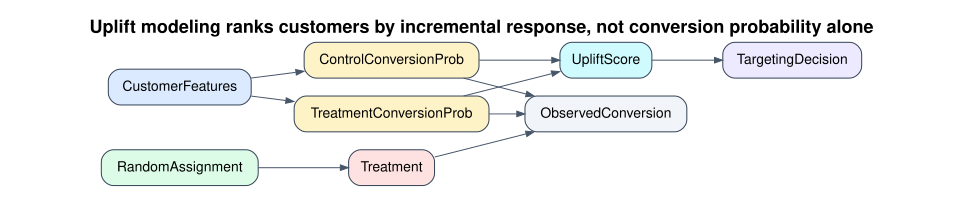

In [3]:
make_dag(
    edges=[
        ("CustomerFeatures", "ControlConversionProb"),
        ("CustomerFeatures", "TreatmentConversionProb"),
        ("RandomAssignment", "Treatment"),
        ("Treatment", "ObservedConversion"),
        ("ControlConversionProb", "ObservedConversion"),
        ("TreatmentConversionProb", "ObservedConversion"),
        ("TreatmentConversionProb", "UpliftScore"),
        ("ControlConversionProb", "UpliftScore"),
        ("UpliftScore", "TargetingDecision"),
    ],
    title="Uplift modeling ranks customers by incremental response, not conversion probability alone",
    node_colors={
        "CustomerFeatures": "#dbeafe",
        "RandomAssignment": "#dcfce7",
        "Treatment": "#fee2e2",
        "ControlConversionProb": "#fef3c7",
        "TreatmentConversionProb": "#fef3c7",
        "ObservedConversion": "#f1f5f9",
        "UpliftScore": "#cffafe",
        "TargetingDecision": "#ede9fe",
    },
)

Uplift modeling is common in marketing, lifecycle messaging, ads, churn prevention, recommendations, healthcare outreach, and credit operations. Rzepakowski and Jaroszewicz (2011) describe uplift trees for single and multiple treatments. Sołtys et al. (2014) discuss ensemble methods for uplift modeling. Devriendt et al. (2022) frame uplift as a ranking problem, which is often how it is used in production. Betlei et al. (2021) emphasize AUUC-style evaluation for choosing models from randomized experiment data.

## 2. The Four Uplift Segments

Uplift practitioners often use four conceptual customer types:

- Persuadables: convert only if treated.
- Sure things: convert with or without treatment.
- Lost causes: do not convert either way.
- Sleeping dogs: would convert without treatment but are less likely to convert if treated.

These are not directly observable labels. They are a mental model based on potential outcomes. For a single customer, we observe either $Y(1)$ or $Y(0)$, never both. The labels are useful because they clarify why a response model can waste money. A response model tends to find sure things. An uplift model tries to find persuadables and avoid sleeping dogs.

## 3. Simulated Campaign Data

We will simulate an e-commerce promotion experiment. Half of customers receive a limited-time discount message; half do not. The outcome is whether the customer buys within seven days.

The promotion has three realistic patterns:

- Price-sensitive customers can be persuaded by the discount.
- Highly loyal customers often buy anyway, so their incremental lift is smaller.
- Some loyal annual-contract customers dislike discount messaging, creating negative lift for a small segment.

The true uplift is known only because this is a simulation.

In [4]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
df = simulate_uplift_campaign()

experiment_summary = pd.DataFrame(
    {
        "quantity": [
            "Customers",
            "Treatment share",
            "Observed conversion rate",
            "Control conversion probability, mean",
            "Treatment conversion probability, mean",
            "True average uplift",
            "Share with negative true uplift",
        ],
        "value": [
            len(df),
            df["treatment"].mean(),
            df["converted"].mean(),
            df["p0"].mean(),
            df["p1"].mean(),
            df["true_cate"].mean(),
            (df["true_cate"] < 0).mean(),
        ],
    }
)

display(experiment_summary)
display(df.head())

,quantity,value
0,Customers,25000.000
1,Treatment share,0.505
2,Observed conversion rate,0.218
3,"Control conversion probability, mean",0.195
4,"Treatment conversion probability, mean",0.238
5,True average uplift,0.043
6,Share with negative true uplift,0.238


,customer_id,intent_score,price_sensitivity,loyalty_score,visits_30d,days_since_last_visit,discount_history,mobile_app,annual_contract,treatment,converted,p0,p1,true_cate,y0,y1
0,1,0.145,0.595,0.785,2,16.761,1,1,0,0,0,0.100,0.132,0.031,0,0
1,2,0.132,0.926,0.537,4,19.831,3,0,1,0,0,0.066,0.163,0.097,0,0
2,3,0.206,0.475,0.763,1,2.755,0,0,1,0,1,0.173,0.133,-0.040,1,0
3,4,0.190,0.532,0.539,1,56.114,2,1,1,0,0,0.049,0.109,0.060,0,0
4,5,0.152,0.289,0.872,2,15.426,1,0,0,1,0,0.106,0.053,-0.052,0,0


The average uplift is the average difference between treatment and control conversion probabilities. In business language, this is the incremental conversion rate caused by the promotion.

A five percentage point uplift can be valuable at scale. It still leaves targeting decisions open because some customers have near-zero or negative lift.

In [5]:
ate_stats = response_rate_difference(df)
ate_table = pd.DataFrame(
    {
        "quantity": [
            "Observed treated conversion rate",
            "Observed control conversion rate",
            "Estimated average uplift",
            "95% CI lower",
            "95% CI upper",
            "True average uplift",
        ],
        "value": [
            ate_stats["treated_rate"],
            ate_stats["control_rate"],
            ate_stats["observed_uplift"],
            ate_stats["ci_low"],
            ate_stats["ci_high"],
            df["true_cate"].mean(),
        ],
    }
)

display(ate_table.round(4))

,quantity,value
0,Observed treated conversion rate,0.239
1,Observed control conversion rate,0.197
2,Estimated average uplift,0.042
3,95% CI lower,0.032
4,95% CI upper,0.052
5,True average uplift,0.043


The randomized experiment recovers the average uplift well. The next question is whether we can rank customers so that the top part of the list has much higher incremental conversion than the average.

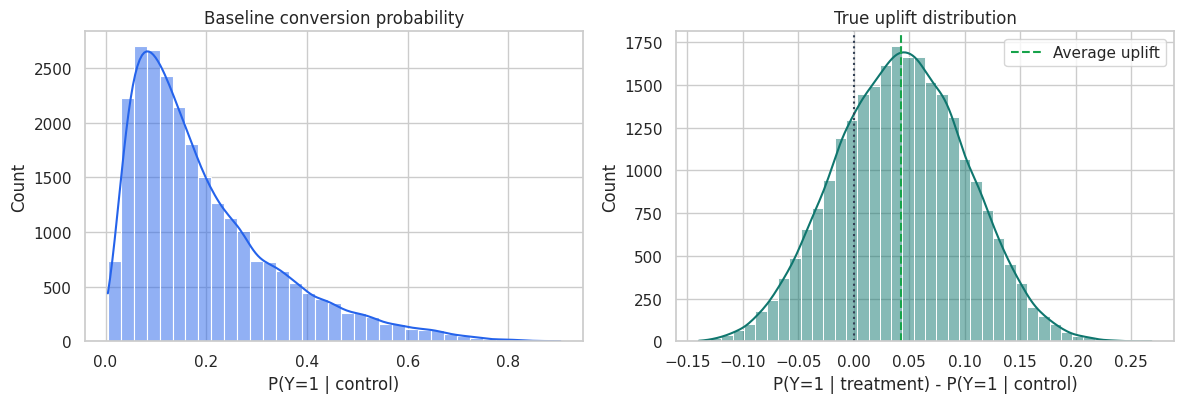

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(df["p0"], bins=35, kde=True, color="#2563eb", ax=axes[0])
axes[0].set_title("Baseline conversion probability")
axes[0].set_xlabel("P(Y=1 | control)")

sns.histplot(df["true_cate"], bins=40, kde=True, color="#0f766e", ax=axes[1])
axes[1].axvline(0, color="#334155", linestyle=":")
axes[1].axvline(df["true_cate"].mean(), color="#16a34a", linestyle="--", label="Average uplift")
axes[1].set_title("True uplift distribution")
axes[1].set_xlabel("P(Y=1 | treatment) - P(Y=1 | control)")
axes[1].legend()

plt.tight_layout()
plt.show()

The left plot is about baseline propensity to buy. The right plot is about incremental responsiveness. These are related but not interchangeable.

treatment targeting should be based on incremental lift. High baseline response and high treatment benefit can point to different customers.

## 4. Conceptual Customer Segments in the Simulation

Because we know $P(Y(0)=1)$ and $\tau(x)$ in the simulation, we can create approximate teaching labels. Real campaign data do not provide these labels. They make the response-versus-uplift distinction concrete.

,customers,baseline_conversion,treated_conversion,true_uplift,price_sensitivity,loyalty,customer_share
teaching_segment,,,,,,,
Persuadables,6017,0.180,0.298,0.118,0.750,0.462,0.241
Moderate uplift,9726,0.181,0.225,0.044,0.570,0.626,0.389
Lost causes,3106,0.064,0.088,0.024,0.530,0.591,0.124
Sure things,2024,0.436,0.456,0.021,0.462,0.713,0.081
Sleeping dogs,4127,0.233,0.189,-0.044,0.308,0.741,0.165


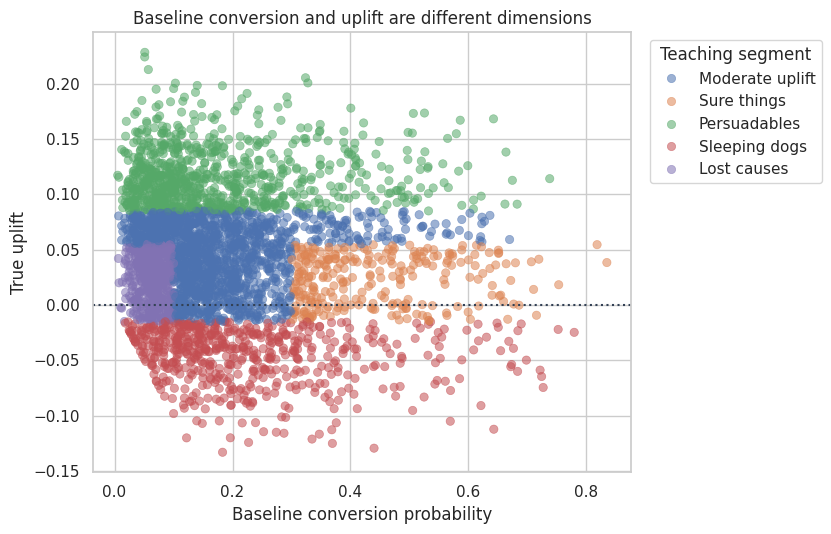

In [7]:
# Build the visualization for the estimates or diagnostics computed above.
def assign_teaching_segment(frame):
    """Assign customers to readable uplift segments for interpretation.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    Returns: a pandas Series of segment labels that summarizes the dominant response pattern for each row."""
    conditions = [
        frame["true_cate"] < -0.015,
        frame["true_cate"] >= 0.085,
        (frame["p0"] >= 0.30) & (frame["true_cate"] < 0.055),
        (frame["p0"] < 0.10) & (frame["true_cate"] < 0.055),
    ]
    choices = ["Sleeping dogs", "Persuadables", "Sure things", "Lost causes"]
    return np.select(conditions, choices, default="Moderate uplift")


df["teaching_segment"] = assign_teaching_segment(df)

segment_table = (
    df.groupby("teaching_segment")
    .agg(
        customers=("customer_id", "count"),
        baseline_conversion=("p0", "mean"),
        treated_conversion=("p1", "mean"),
        true_uplift=("true_cate", "mean"),
        price_sensitivity=("price_sensitivity", "mean"),
        loyalty=("loyalty_score", "mean"),
    )
    .assign(customer_share=lambda x: x["customers"] / len(df))
    .sort_values("true_uplift", ascending=False)
)

display(segment_table.round(3))

plot_sample = df.sample(3500, random_state=22)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(
    data=plot_sample,
    x="p0",
    y="true_cate",
    hue="teaching_segment",
    alpha=0.55,
    edgecolor=None,
    ax=ax,
)
ax.axhline(0, color="#334155", linestyle=":")
ax.set_title("Baseline conversion and uplift are different dimensions")
ax.set_xlabel("Baseline conversion probability")
ax.set_ylabel("True uplift")
ax.legend(title="Teaching segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The important contrast is between sure things and persuadables. Sure things have high baseline conversion. Persuadables have high incremental conversion. A campaign that is judged by raw response rate can look good while spending budget on sure things.

## 5. Train-Test Split and Candidate Scores

We will compare four scoring strategies.

1. Response model: predicts conversion among treated customers. This is common in marketing, but it is not an uplift model.
2. Two-model uplift score: fit one model for treated conversion and one model for control conversion, then subtract probabilities.
3. Interaction model: fit a single classifier with treatment and treatment-feature interactions, then predict each customer twice, once as treated and once as control.
4. Transformed-outcome model: convert each observed row into an unbiased noisy signal of uplift, then regress that signal on features.

The next notebook will go deeper into metalearners. Here the goal is to understand the modeling target and evaluation workflow.

In [8]:
feature_cols = [
    "intent_score",
    "price_sensitivity",
    "loyalty_score",
    "visits_30d",
    "days_since_last_visit",
    "discount_history",
    "mobile_app",
    "annual_contract",
]

strata = df["treatment"].astype(str) + "_" + df["converted"].astype(str)
train_df, test_df = train_test_split(df, test_size=0.40, random_state=19, stratify=strata)

split_summary = pd.DataFrame(
    {
        "sample": ["Train", "Test"],
        "n": [len(train_df), len(test_df)],
        "treatment_share": [train_df["treatment"].mean(), test_df["treatment"].mean()],
        "conversion_rate": [train_df["converted"].mean(), test_df["converted"].mean()],
        "true_average_uplift": [train_df["true_cate"].mean(), test_df["true_cate"].mean()],
    }
)

display(split_summary.round(4))

,sample,n,treatment_share,conversion_rate,true_average_uplift
0,Train,15000,0.505,0.218,0.043
1,Test,10000,0.505,0.218,0.044


This is where the calculation starts to matter for the decision. The campaign should be judged by incremental response among contacted customers, since baseline conversion alone can mislead.

In [9]:
# 1. Response model: predicts conversion among treated customers.
response_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=60,
    random_state=101,
    n_jobs=-1,
)
response_model.fit(
    train_df.loc[train_df["treatment"] == 1, feature_cols],
    train_df.loc[train_df["treatment"] == 1, "converted"],
)

# 2. Two-model uplift score.
treated_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=60,
    random_state=102,
    n_jobs=-1,
)
control_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=60,
    random_state=103,
    n_jobs=-1,
)
treated_model.fit(
    train_df.loc[train_df["treatment"] == 1, feature_cols],
    train_df.loc[train_df["treatment"] == 1, "converted"],
)
control_model.fit(
    train_df.loc[train_df["treatment"] == 0, feature_cols],
    train_df.loc[train_df["treatment"] == 0, "converted"],
)

# 3. Single interaction model.
X_train_interaction = make_interaction_frame(train_df, feature_cols)
interaction_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, C=0.4),
)
interaction_model.fit(X_train_interaction, train_df["converted"])

# 4. Transformed-outcome model.
propensity = 0.5
transformed_outcome = train_df["converted"] * (
    train_df["treatment"] / propensity - (1 - train_df["treatment"]) / (1 - propensity)
)
transformed_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=80,
    random_state=104,
    n_jobs=-1,
)
transformed_model.fit(train_df[feature_cols], transformed_outcome)

print("Models fit on randomized treatment-control experiment data.")

Models fit on randomized treatment-control experiment data.


The transformed outcome used above is:

$$
Y_i^* = Y_i\left(\frac{W_i}{e} - \frac{1-W_i}{1-e}\right)
$$

where $e=P(W=1)$. Under random assignment:

$$
E[Y_i^* \mid X_i=x] = E[Y(1)-Y(0) \mid X_i=x]
$$

This transformed target is noisy, but it lets us use ordinary regression software to produce an uplift score.

In [10]:
# Fit the models for this section and assemble the estimates used in the discussion.
test_scored = test_df.copy()

test_scored["score_response"] = response_model.predict_proba(test_scored[feature_cols])[:, 1]

test_scored["score_two_model"] = (
    treated_model.predict_proba(test_scored[feature_cols])[:, 1]
    - control_model.predict_proba(test_scored[feature_cols])[:, 1]
)

X_test_control = make_interaction_frame(test_scored.assign(treatment=0), feature_cols, treatment_value=0)
X_test_treated = make_interaction_frame(test_scored.assign(treatment=1), feature_cols, treatment_value=1)
test_scored["score_interaction"] = (
    interaction_model.predict_proba(X_test_treated)[:, 1]
    - interaction_model.predict_proba(X_test_control)[:, 1]
)

test_scored["score_transformed"] = transformed_model.predict(test_scored[feature_cols])

display(
    test_scored[
        [
            "customer_id",
            "converted",
            "treatment",
            "p0",
            "true_cate",
            "score_response",
            "score_two_model",
            "score_interaction",
            "score_transformed",
        ]
    ].head(10).round(4)
)

,customer_id,converted,treatment,p0,true_cate,score_response,score_two_model,score_interaction,score_transformed
6933,6934,0,1,0.032,0.127,0.184,0.147,0.068,0.176
14465,14466,0,1,0.118,0.157,0.269,0.085,0.154,0.040
23503,23504,1,0,0.368,-0.030,0.335,-0.047,-0.107,0.108
17025,17026,0,1,0.088,0.129,0.216,0.084,0.104,0.110
22270,22271,0,1,0.513,0.097,0.547,-0.004,0.045,-0.158
2263,2264,0,1,0.133,-0.051,0.097,-0.042,-0.028,-0.035
5420,5421,0,1,0.349,0.048,0.334,-0.040,0.015,-0.021
9292,9293,0,1,0.161,-0.003,0.133,-0.068,0.022,-0.139
15691,15692,0,1,0.133,0.035,0.213,0.055,0.048,0.075
7770,7771,0,0,0.373,0.076,0.376,-0.006,0.077,0.073


Every model produces a score, but the scores mean different things. The response score estimates conversion under treatment. The other three scores estimate incremental conversion caused by treatment.

treatment targeting should be based on incremental lift. High baseline response and high treatment benefit can point to different customers.

## 6. Why Classification Metrics Can Mislead

A response model can have a strong AUC because it predicts who converts when treated. But targeting by this score can still be inefficient if many high-scoring customers would have converted without treatment.

We will compare two kinds of metrics:

- Treated-response AUC and average precision: ordinary predictive metrics among treated customers.
- Uplift usefulness: correlation with true uplift in the simulation, observed uplift in the top 20%, and true mean uplift in the top 20%.

In real data, the true-uplift columns are unavailable. The observed top-bin lift is the practical experimental check.

In [11]:
score_map = {
    "Response model": "score_response",
    "Two-model uplift": "score_two_model",
    "Interaction uplift": "score_interaction",
    "Transformed outcome": "score_transformed",
}

comparison_rows = []
for model_name, score_col in score_map.items():
    top20 = top_fraction_mask(test_scored, score_col, fraction=0.20)
    top20_stats = response_rate_difference(test_scored, top20)
    treated_test = test_scored.loc[test_scored["treatment"] == 1]
    comparison_rows.append(
        {
            "model": model_name,
            "treated_response_auc": roc_auc_score(treated_test["converted"], treated_test[score_col]),
            "treated_average_precision": average_precision_score(treated_test["converted"], treated_test[score_col]),
            "corr_with_true_uplift": np.corrcoef(test_scored[score_col], test_scored["true_cate"])[0, 1],
            "observed_uplift_top20": top20_stats["observed_uplift"],
            "true_uplift_top20": test_scored.loc[top20, "true_cate"].mean(),
            "negative_uplift_share_top20": (test_scored.loc[top20, "true_cate"] < 0).mean(),
        }
    )

comparison_table = pd.DataFrame(comparison_rows).sort_values("true_uplift_top20", ascending=False)
display(comparison_table.round(4))

,model,treated_response_auc,treated_average_precision,corr_with_true_uplift,observed_uplift_top20,true_uplift_top20,negative_uplift_share_top20
2,Interaction uplift,0.492,0.257,0.841,0.069,0.116,0.000
1,Two-model uplift,0.502,0.249,0.752,0.093,0.107,0.003
3,Transformed outcome,0.484,0.260,0.590,0.084,0.100,0.034
0,Response model,0.710,0.448,0.283,0.065,0.061,0.181


The response model can score well on treated-response AUC but still be a weaker targeting rule. The uplift models are not trying to predict conversion. They are trying to predict incremental conversion.

This is the first major habit shift: do not pick an uplift model using ordinary classification accuracy, AUC, or log loss alone.

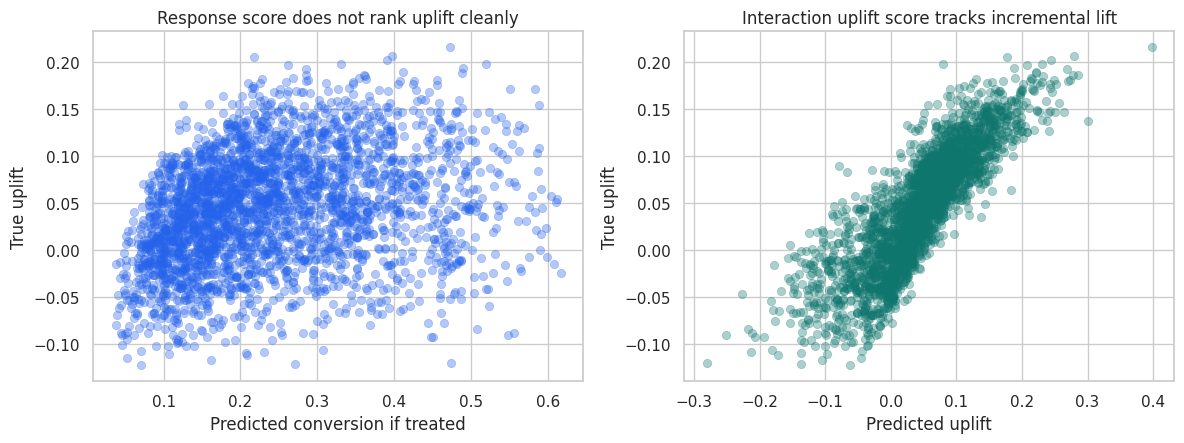

In [12]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_sample = test_scored.sample(3000, random_state=35)

sns.scatterplot(
    data=plot_sample,
    x="score_response",
    y="true_cate",
    alpha=0.35,
    edgecolor=None,
    color="#2563eb",
    ax=axes[0],
)
axes[0].set_title("Response score does not rank uplift cleanly")
axes[0].set_xlabel("Predicted conversion if treated")
axes[0].set_ylabel("True uplift")

sns.scatterplot(
    data=plot_sample,
    x="score_interaction",
    y="true_cate",
    alpha=0.35,
    edgecolor=None,
    color="#0f766e",
    ax=axes[1],
)
axes[1].set_title("Interaction uplift score tracks incremental lift")
axes[1].set_xlabel("Predicted uplift")
axes[1].set_ylabel("True uplift")

plt.tight_layout()
plt.show()

The response score is strongly related to baseline conversion. The uplift score is more directly related to incremental response. This distinction is the reason uplift modeling exists.

treatment targeting should be based on incremental lift. High baseline response and high treatment benefit can point to different customers.

## 7. Decile Lift Tables

A decile table is often the most practical way to explain uplift results to stakeholders. Sort customers by the model score, split them into ten equally sized groups, and estimate treatment-control lift inside each group.

For a useful uplift model, the top deciles should have much higher observed treatment-control differences than the lower deciles.

,decile,n,treated_rate,control_rate,observed_uplift,ci_low,ci_high,true_uplift_mean,baseline_conversion_mean
0,D1 highest,1000,0.299,0.195,0.104,0.051,0.157,0.133,0.201
1,D2,1000,0.263,0.229,0.034,-0.019,0.088,0.100,0.177
2,D3,1000,0.249,0.167,0.082,0.032,0.132,0.081,0.158
3,D4,1000,0.206,0.146,0.061,0.014,0.108,0.065,0.148
4,D5,1000,0.191,0.151,0.039,-0.007,0.086,0.052,0.143
5,D6,1000,0.184,0.132,0.051,0.006,0.097,0.036,0.133
6,D7,1000,0.168,0.132,0.037,-0.008,0.081,0.017,0.142
7,D8,1000,0.186,0.182,0.004,-0.045,0.052,-0.002,0.178
8,D9,1000,0.253,0.251,0.002,-0.052,0.056,-0.013,0.261
9,D10,1000,0.392,0.388,0.005,-0.056,0.065,-0.033,0.412


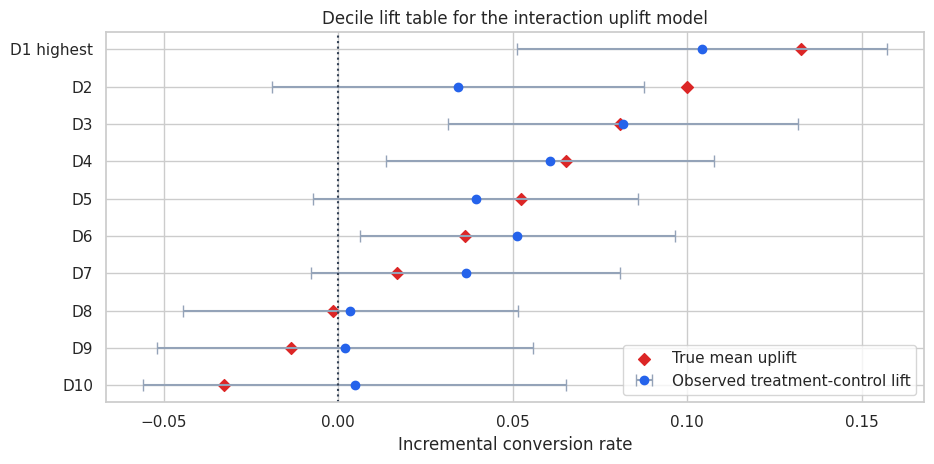

In [13]:
# Fit the models for this section and assemble the estimates used in the discussion.
interaction_deciles = decile_lift_table(test_scored, "score_interaction")
display(interaction_deciles.round(4))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(interaction_deciles))
ax.errorbar(
    interaction_deciles["observed_uplift"],
    y,
    xerr=np.vstack(
        [
            interaction_deciles["observed_uplift"] - interaction_deciles["ci_low"],
            interaction_deciles["ci_high"] - interaction_deciles["observed_uplift"],
        ]
    ),
    fmt="o",
    color="#2563eb",
    ecolor="#94a3b8",
    capsize=4,
    label="Observed treatment-control lift",
)
ax.scatter(
    interaction_deciles["true_uplift_mean"],
    y,
    color="#dc2626",
    marker="D",
    label="True mean uplift",
)
ax.axvline(0, color="#334155", linestyle=":")
ax.set_yticks(y)
ax.set_yticklabels(interaction_deciles["decile"])
ax.set_xlabel("Incremental conversion rate")
ax.set_title("Decile lift table for the interaction uplift model")
ax.invert_yaxis()
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The top deciles show high incremental conversion. Lower deciles are weaker and may include customers who should not receive the promotion.

In real applications, this table should be computed on a holdout experiment or on future randomized traffic. It should not be trusted if it is computed on the same data used to tune many competing models.

## 8. Cumulative Uplift Curves and AUUC

A cumulative uplift curve asks: if we contact the top $k$ percent of customers according to the score, how many incremental conversions do we estimate?

For a randomized experiment with treatment probability $e$, an inverse-probability weighted estimate of incremental conversions in a selected set $S$ is:

$$
\widehat{\Delta}(S) = \sum_{i \in S} Y_i\left(\frac{W_i}{e} - \frac{1-W_i}{1-e}\right)
$$

Dividing by the total number of eligible customers gives incremental conversions per eligible customer. Multiplying by 1000 gives incremental conversions per 1000 eligible customers.

The area under this curve is an AUUC-style summary. Larger is better for ranking customers by incremental response.

,model,auuc
4,Oracle true uplift,0.039
1,Two-model uplift,0.034
2,Interaction uplift,0.033
0,Response model,0.029
3,Transformed outcome,0.028


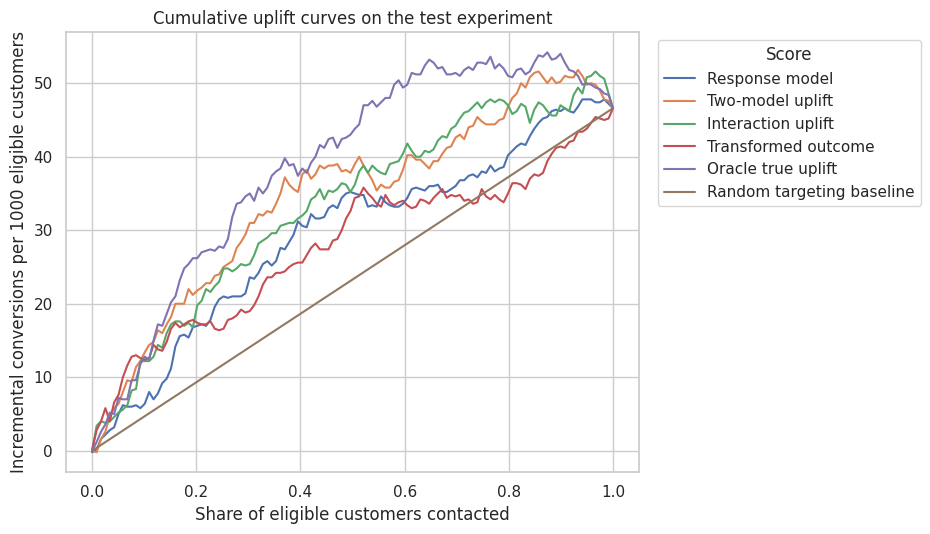

In [14]:
# Fit the models for this section and assemble the estimates used in the discussion.
curve_frames = []
auuc_rows = []
for model_name, score_col in score_map.items():
    curve = cumulative_uplift_curve(test_scored, score_col)
    curve["model"] = model_name
    curve_frames.append(curve)
    auuc_rows.append({"model": model_name, "auuc": auuc_from_curve(curve)})

# Oracle curve is available only in the simulation.
oracle_curve = cumulative_uplift_curve(test_scored, "true_cate")
oracle_curve["model"] = "Oracle true uplift"
curve_frames.append(oracle_curve)
auuc_rows.append({"model": "Oracle true uplift", "auuc": auuc_from_curve(oracle_curve)})

curves = pd.concat(curve_frames, ignore_index=True)
auuc_table = pd.DataFrame(auuc_rows).sort_values("auuc", ascending=False)

overall_curve_end = cumulative_uplift_curve(test_scored.assign(random_score=0.0), "random_score")[
    "incremental_per_eligible"
].iloc[-1]
random_baseline = pd.DataFrame(
    {
        "contact_share": np.linspace(0, 1, 121),
        "incremental_per_eligible": np.linspace(0, overall_curve_end, 121),
    }
)
random_baseline["incremental_conversions_per_1000"] = 1000 * random_baseline["incremental_per_eligible"]
random_baseline["model"] = "Random targeting baseline"

display(auuc_table.round(5))

fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.lineplot(
    data=pd.concat([curves, random_baseline], ignore_index=True),
    x="contact_share",
    y="incremental_conversions_per_1000",
    hue="model",
    ax=ax,
)
ax.set_title("Cumulative uplift curves on the test experiment")
ax.set_xlabel("Share of eligible customers contacted")
ax.set_ylabel("Incremental conversions per 1000 eligible customers")
ax.legend(title="Score", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The curve is more informative than a single metric. A model can be excellent in the top 10% and mediocre after that, which is fine if campaign capacity is 10%. If capacity is 60%, a different model may be preferred.

Devriendt et al. (2022) note that uplift modeling is fundamentally a ranking problem. Betlei et al. (2021) discuss AUUC as a model-selection criterion when the future policy treats the highest-scored individuals.

## 9. Policy Value With Margin and Cost

Incremental conversion is not enough. Campaigns have value and cost.

Suppose one incremental conversion is worth 80 dollars in contribution margin, and each contacted customer costs 5 dollars in discount expense, messaging, or customer-experience risk.

For a selected group $S$, the true expected net value per eligible customer is:

$$
\frac{|S|}{N}\left(E[\tau(X) \mid X \in S] \times margin - cost\right)
$$

In real data, the true uplift term is unavailable, so we use randomized holdout estimates and continue experimenting.

In [15]:
# Fit the models for this section and assemble the estimates used in the discussion.
def policy_value_table(frame, score_map, fractions, margin=80.0, contact_cost=5.0, propensity=0.5):
    """Compute policy value table for the cate and uplift modeling example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `score_map`: mapping from policy or model names to score columns used for targeting comparisons.
    - `fractions`: sequence of targeting fractions used to trace a value or uplift curve.
    - `margin`: business margin or value per incremental successful outcome.
    - `contact_cost`: per-unit cost of contacting or treating a selected unit.
    - `propensity`: propensity value used by `policy_value_table`.
    Returns: a pandas table or array describing policy value across targeting thresholds."""
    rows = []
    for model_name, score_col in score_map.items():
        for fraction in fractions:
            mask = top_fraction_mask(frame, score_col, fraction=fraction)
            selected = frame.loc[mask].copy()
            ipw_incremental = selected["converted"] * (
                selected["treatment"] / propensity - (1 - selected["treatment"]) / (1 - propensity)
            )
            rows.append(
                {
                    "model": model_name,
                    "contact_share": fraction,
                    "true_uplift_targeted": selected["true_cate"].mean(),
                    "observed_uplift_targeted": ipw_incremental.mean(),
                    "true_net_value_per_eligible": fraction
                    * (selected["true_cate"].mean() * margin - contact_cost),
                    "observed_net_value_per_eligible": fraction
                    * (ipw_incremental.mean() * margin - contact_cost),
                    "negative_uplift_share_targeted": (selected["true_cate"] < 0).mean(),
                }
            )
    return pd.DataFrame(rows)


fractions = [0.10, 0.20, 0.30, 0.50, 1.00]
policy_scores = {
    "Response model": "score_response",
    "Two-model uplift": "score_two_model",
    "Interaction uplift": "score_interaction",
    "Transformed outcome": "score_transformed",
    "Oracle true uplift": "true_cate",
}
policy_table = policy_value_table(test_scored, policy_scores, fractions)

display(
    policy_table.sort_values(["contact_share", "true_net_value_per_eligible"], ascending=[True, False]).round(4)
)

,model,contact_share,true_uplift_targeted,observed_uplift_targeted,true_net_value_per_eligible,observed_net_value_per_eligible,negative_uplift_share_targeted
20,Oracle true uplift,0.100,0.145,0.126,0.663,0.508,0.000
10,Interaction uplift,0.100,0.133,0.122,0.560,0.476,0.000
5,Two-model uplift,0.100,0.119,0.134,0.453,0.572,0.001
15,Transformed outcome,0.100,0.109,0.124,0.375,0.492,0.024
0,Response model,0.100,0.059,0.062,-0.030,-0.004,0.197
21,Oracle true uplift,0.200,0.126,0.130,1.008,1.080,0.000
11,Interaction uplift,0.200,0.116,0.090,0.860,0.440,0.000
6,Two-model uplift,0.200,0.107,0.108,0.707,0.728,0.003
16,Transformed outcome,0.200,0.100,0.092,0.597,0.472,0.034
1,Response model,0.200,0.061,0.085,-0.029,0.360,0.181


The practical takeaway is simple. A useful uplift score changes the contact list in a way that raises incremental conversions.

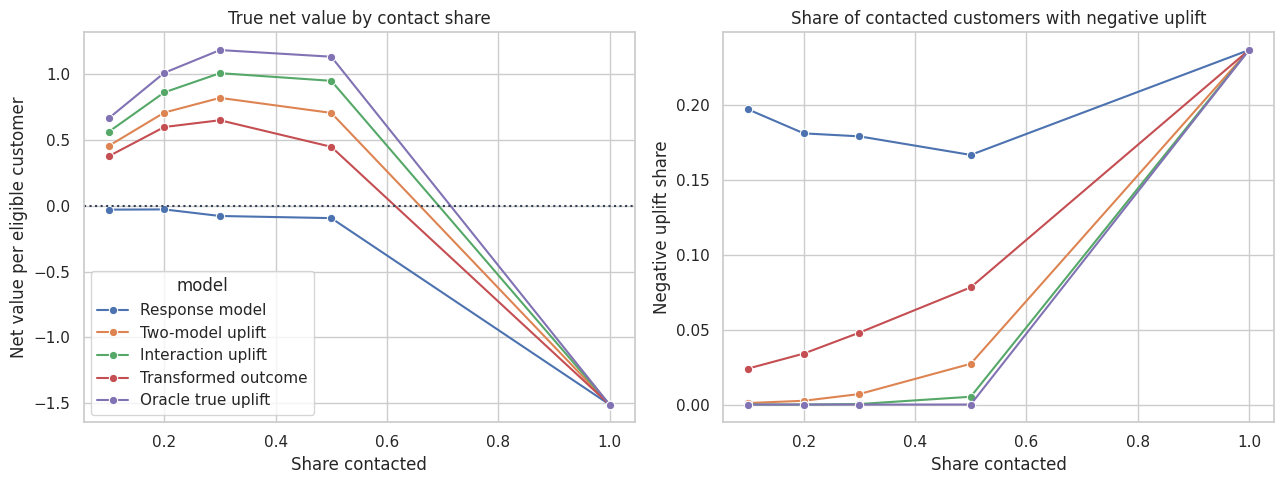

In [16]:
# Fit the models for this section and assemble the estimates used in the discussion.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(
    data=policy_table,
    x="contact_share",
    y="true_net_value_per_eligible",
    hue="model",
    marker="o",
    ax=axes[0],
)
axes[0].axhline(0, color="#334155", linestyle=":")
axes[0].set_title("True net value by contact share")
axes[0].set_xlabel("Share contacted")
axes[0].set_ylabel("Net value per eligible customer")

sns.lineplot(
    data=policy_table,
    x="contact_share",
    y="negative_uplift_share_targeted",
    hue="model",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Share of contacted customers with negative uplift")
axes[1].set_xlabel("Share contacted")
axes[1].set_ylabel("Negative uplift share")
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

The interaction uplift model creates more value than the response model at constrained contact shares. The response model often contacts customers with high conversion probability, but some of those customers are sure things.

The negative-uplift plot is a useful guardrail. It tells us whether a targeting rule is accidentally contacting many sleeping dogs.

## 10. Overlap Between Response Targeting and Uplift Targeting

A common stakeholder question is: "Are we really targeting different customers?" We can answer by comparing the top lists.

In [17]:
# Fit the models for this section and assemble the estimates used in the discussion.
top20_response = top_fraction_mask(test_scored, "score_response", fraction=0.20)
top20_uplift = top_fraction_mask(test_scored, "score_interaction", fraction=0.20)

test_scored["top20_response_model"] = top20_response
_test_overlap = test_scored.copy()
_test_overlap["top20_interaction_uplift"] = top20_uplift
_test_overlap["targeting_group"] = np.select(
    [
        top20_response & top20_uplift,
        top20_response & ~top20_uplift,
        ~top20_response & top20_uplift,
    ],
    ["Both lists", "Response only", "Uplift only"],
    default="Neither top list",
)

overlap_table = (
    _test_overlap.groupby("targeting_group")
    .agg(
        customers=("customer_id", "count"),
        baseline_conversion=("p0", "mean"),
        true_uplift=("true_cate", "mean"),
        price_sensitivity=("price_sensitivity", "mean"),
        loyalty_score=("loyalty_score", "mean"),
        negative_uplift_share=("true_cate", lambda x: (x < 0).mean()),
    )
    .assign(customer_share=lambda x: x["customers"] / len(_test_overlap))
    .sort_values("true_uplift", ascending=False)
)

display(overlap_table.round(4))

,customers,baseline_conversion,true_uplift,price_sensitivity,loyalty_score,negative_uplift_share,customer_share
targeting_group,,,,,,,
Both lists,630,0.305,0.126,0.734,0.519,0.000,0.063
Uplift only,1370,0.136,0.112,0.729,0.473,0.000,0.137
Response only,1370,0.466,0.031,0.497,0.713,0.264,0.137
Neither top list,6630,0.141,0.024,0.522,0.623,0.302,0.663


The "response only" group tends to have stronger baseline conversion than incremental lift. The "uplift only" group is often more price-sensitive and less certain to buy without treatment. This is exactly the strategic difference between conversion prediction and uplift modeling.

## 11. Practical Modeling Notes

Several implementation details matter in real projects:

- Keep a randomized holdout. Without it, uplift validation becomes fragile.
- Use pre-treatment features only. Post-treatment behavior can leak mediators or outcomes into the model.
- Check treatment and control counts in top bins. Tiny cells produce noisy lift estimates.
- Evaluate at the contact share the business can actually use.
- Include contact costs, margin, opt-outs, and support load in policy value.
- Report uncertainty in top-bin lift, not only point estimates.
- Monitor drift. A model trained on one campaign can decay when pricing, seasonality, audience mix, or offer design changes.
- Avoid claiming individual-level truth. Uplift is usually reliable at ranked-group or segment level, not as a literal person-by-person causal fact.

Uplift modeling is most credible when it is embedded in an experimentation program: learn from randomized treatment-control data, deploy to a constrained audience, and keep randomized exploration so the model can be audited and improved.

## 12. Industry Readout Template

A good uplift readout for a promotion or retention campaign might include:

1. Average lift: treatment increased conversion by the experimental treatment-control difference.
2. Targeting objective: maximize incremental conversions per contacted customer, with raw conversion rate used only as context.
3. Recommended score: use the uplift score, not the treated-response score.
4. Capacity decision: contact the top 20% or 30%, depending on marginal net value.
5. Avoided waste: the response model over-targets sure things; the uplift model finds more persuadables.
6. Risk control: exclude bins with negative or near-zero lift unless there is another strategic reason to contact them.
7. Validation plan: keep a randomized holdout and report decile lift after launch.

This makes the analysis legible to marketing, product, finance, and data science at the same time.

In [18]:
best_fraction = 0.20
readout_rows = []
for model_name in ["Response model", "Interaction uplift", "Oracle true uplift"]:
    row = policy_table.loc[
        (policy_table["model"] == model_name) & (policy_table["contact_share"] == best_fraction)
    ].iloc[0]
    readout_rows.append(
        {
            "targeting_rule": model_name,
            "contact_share": best_fraction,
            "true_uplift_targeted": row["true_uplift_targeted"],
            "true_net_value_per_eligible": row["true_net_value_per_eligible"],
            "negative_uplift_share_targeted": row["negative_uplift_share_targeted"],
        }
    )

readout_table = pd.DataFrame(readout_rows)
display(readout_table.round(4))

,targeting_rule,contact_share,true_uplift_targeted,true_net_value_per_eligible,negative_uplift_share_targeted
0,Response model,0.200,0.061,-0.029,0.181
1,Interaction uplift,0.200,0.116,0.860,0.000
2,Oracle true uplift,0.200,0.126,1.008,0.000


The interaction uplift rule is imperfect and still moves the campaign in the right direction. It gets closer to the oracle rule than the response model because it is solving the correct causal ranking problem.

## Key Takeaways

- Uplift for a binary outcome is the CATE expressed as an incremental probability of success.
- Response modeling asks who will convert; uplift modeling asks whose conversion probability changes because of treatment.
- Sure things can make a campaign look good while wasting treatment budget.
- A response model can have good AUC and still be a weak targeting rule.
- Decile lift tables and cumulative uplift curves are practical tools for model evaluation.
- AUUC-style metrics summarize ranking quality, but business decisions should still use campaign capacity, margin, cost, and guardrails.
- The most credible uplift systems keep randomized holdouts so targeting performance can be measured after deployment.

## References

Betlei, A., Diemert, E., & Amini, M.-R. (2021). Uplift modeling with generalization guarantees. *Proceedings of the 27th ACM SIGKDD Conference on Knowledge Discovery & Data Mining*, 55-65. [https://doi.org/10.1145/3447548.3467395](https://doi.org/10.1145/3447548.3467395)

Devriendt, F., Van Belle, J., Guns, T., & Verbeke, W. (2022). Learning to rank for uplift modeling. *IEEE Transactions on Knowledge and Data Engineering, 34*(10), 4888-4904. [https://doi.org/10.1109/TKDE.2020.3048510](https://doi.org/10.1109/TKDE.2020.3048510)

Kunzel, S. R., Sekhon, J. S., Bickel, P. J., & Yu, B. (2019). Metalearners for estimating heterogeneous treatment effects using machine learning. *Proceedings of the National Academy of Sciences, 116*(10), 4156-4165. [https://doi.org/10.1073/pnas.1804597116](https://doi.org/10.1073/pnas.1804597116)

Olaya, D., Coussement, K., & Verbeke, W. (2020). A survey and benchmarking study of multitreatment uplift modeling. *Data Mining and Knowledge Discovery, 34*(2), 273-308. [https://doi.org/10.1007/s10618-019-00670-y](https://doi.org/10.1007/s10618-019-00670-y)

Rzepakowski, P., & Jaroszewicz, S. (2012). Decision trees for uplift modeling with single and multiple treatments. *Knowledge and Information Systems, 32*(2), 303-327. [https://doi.org/10.1007/s10115-011-0434-0](https://doi.org/10.1007/s10115-011-0434-0)

Sołtys, M., Jaroszewicz, S., & Rzepakowski, P. (2015). Ensemble methods for uplift modeling. *Data Mining and Knowledge Discovery, 29*(6), 1531-1559. [https://doi.org/10.1007/s10618-014-0383-9](https://doi.org/10.1007/s10618-014-0383-9)
